<h2><b>Parameter Initialization Methods</b></h2>

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py
import time
import sklearn
import sklearn.datasets

<h3><b>A Deep Feed Forward Neural Network</b></h3>

In [61]:
def layer_sizes(X, Y, num_hidden_units):
    
    num_input_units = [X.shape[0]]
    num_output_units = [Y.shape[0]]
    num_hidden_units = list(num_hidden_units)
    
    num_layer_units = list(num_input_units + num_hidden_units + num_output_units)
    
    return num_layer_units


# implement parameter initialization function using He method
def initialize_parameters_he(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(2 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters


def initialize_parameters_deep(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) / np.sqrt(num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using Xavier method
def initialize_parameters_xavier(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(1 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using big random variables
def initialize_parameters_random1(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 10
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using small random variables
def initialize_parameters_random2(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

# implement parameter initialization function using small random variables for both W and b
def initialize_parameters_random3(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.random.randn(num_layer_units[l], 1) * 0.01
        
    return parameters

# implement parameter initialization function using uniform random variables
def initialize_parameters_random4(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.rand(num_layer_units[l], num_layer_units[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters


def sigmoid(Z):

    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache


def relu(Z):

    A = np.maximum(0, Z)
    cache = Z
    
    return A, cache
    

def derivative_sigmoid(dA, cache):

    A = 1 / (1 + np.exp(cache))
    dZ = dA * A * (1 - A)
    assert (dZ.shape == cache.shape)
    
    return dZ


def derivative_relu(dA, cache):

    dZ = np.array(dA, copy=True)
    dZ = np.maximum(0, cache)
    assert (dZ.shape == cache.shape)
    
    return dZ


def helper_forward1(A_prev, W, b):

    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)

    return Z, cache


def helper_forward2(A_prev, W, b, activation):

    if activation == "relu":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = relu(Z=Z)
    elif activation == "sigmoid":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = sigmoid(Z=Z)
        
    cache = (linear_cache, activation_cache)

    return A, cache


def forward_propagation(X, parameters, hidden_activation, output_activation):

    caches = []
    A = X
    num_layers = len(parameters) // 2


    for l in range(1, num_layers):
        A_prev = A
        A, cache = helper_forward2(A_prev=A_prev, W=parameters[f"W{l}"], b=parameters[f"b{l}"], activation=hidden_activation)
        caches.append(cache)

    A, cache = helper_forward2(A_prev=A, W=parameters[f"W{num_layers}"], b=parameters[f"b{num_layers}"], activation=output_activation)
    caches.append(cache) 
    
    return A, caches
    

def compute_cost(A, Y):

    cost = - np.sum(np.multiply(Y, np.log(A)) + np.multiply(1 - Y, np.log(1 - A))) / Y.shape[1]

    return cost


def helper_backward1(dZ, cache):

    A_prev, W, b = cache

    dW = np.dot(dZ, A_prev.T) / A_prev.shape[1]
    db = np.sum(dZ, axis=1, keepdims=True) / A_prev.shape[1]
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def helper_backward2(dA, cache, activation):

    linear_cache, activation_cache = cache

    if activation == "relu":

        dZ = derivative_relu(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)
        
    elif activation == "sigmoid":

        dZ = derivative_sigmoid(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)

    return dA_prev, dW, db


def backward_propagation(A, Y, caches, hidden_activation, output_activation):

    grads = {}
    L = len(caches)

    dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))

    
    for l in reversed(range(L - 1)):

        current_cache = caches[l]
        dA_prev, dW, db = helper_backward2(dA=dA, cache=current_cache, activation=hidden_activation)
        grads[f"dW{l+1}"] = dW
        grads[f"db{l+1}"] = db
        grads[f"dA{l}"] = dA_prev
        
    current_cache = caches[-1]
    dA_prev, dW, db = helper_backward2(dA=dA, cache=current_cache, activation=output_activation)
    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db
    grads[f"dA{L-1}"] = dA_prev

    return grads

def update_parameters(parameters, grads, learning_rate):

    L = len(parameters) // 2

    for l in range(1, L+1):
        
        parameters[f"W{l}"] -= grads[f"dW{l}"] * learning_rate
        parameters[f"b{l}"] -= grads[f"db{l}"] * learning_rate

    return parameters

def predict(X, parameters, hidden_activation, output_activation):
    
    predicted = np.zeros((1, X.shape[1]))
    
    probabilities, caches = forward_propagation(X=X, parameters=parameters, hidden_activation=hidden_activation, output_activation=output_activation)
    
    predicted[0, :] = (probabilities > 0.5)

    return predicted


def accuracy(predicted, Y):
    
    accuracy = np.sum((predicted == Y) / Y.shape[1])
    
    return accuracy

def train(X, Y, parameters, hidden_activation, output_activation, num_epochs, learning_rate, print_cost, epsilon):

    train_cost = []
    
    durations = []
    for i in range(1, num_epochs+1):
        tic = time.time()
        A, caches = forward_propagation(X=X, parameters=parameters, hidden_activation=hidden_activation, output_activation=output_activation)
        cost = compute_cost(A=A, Y=Y)
        train_cost.append(cost)
        grads = backward_propagation(A=A, Y=Y, caches=caches, hidden_activation=hidden_activation, output_activation=output_activation)
        parameters = update_parameters(parameters=parameters, grads=grads, learning_rate=learning_rate)
        toc = time.time()
        durations.append(toc - tic)
        if print_cost and i % epsilon == 0:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(sum(durations[i-epsilon: i]), 3)}")
        if i == num_epochs:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(toc - tic, 3)}")
                
    
    predicted = predict(X=X, parameters=parameters, hidden_activation=hidden_activation, output_activation=output_activation)   

    acuuracy = accuracy(predicted=predicted, Y=Y) 

    return (parameters, predicted, acuuracy, train_cost)

def model(X_train, Y_train, X_test, Y_test, num_hidden_units, hidden_activation="relu", output_activation="sigmoid", init="he", num_epochs=10000, learning_rate=1e-4, print_cost=True, epsilon=1000):

    
    num_layer_units = layer_sizes(X=X_train, Y=Y_train, num_hidden_units=num_hidden_units)

    if init == "he":
        parameters = initialize_parameters_he(num_layer_units=num_layer_units)
    elif init == "xavier":
        parameters = initialize_parameters_xavier(num_layer_units=num_layer_units)
    elif init == "big_random":
        parameters = initialize_parameters_random1(num_layer_units=num_layer_units)
    elif init == "small_random":
        parameters = initialize_parameters_random2(num_layer_units=num_layer_units)
    elif init == "wb_random":
        parameters = initialize_parameters_random3(num_layer_units=num_layer_units)
    elif init == "uniform_random":
        parameters = initialize_parameters_random4(num_layer_units=num_layer_units)
    elif init == "deep":
        parameters = initialize_parameters_deep(num_layer_units=num_layer_units)

    if print_cost:
        print("___"*33)
        print(f"NN_Model with {len(num_hidden_units)+1} layers; Number of Epochs: {num_epochs}; Learning Rate: {learning_rate}; Initialization Method: {init}")
        print("___"*33)
   
    
    train_params = train(X=X_train, Y=Y_train, parameters=parameters, hidden_activation=hidden_activation, output_activation=output_activation, 
                         num_epochs=num_epochs, learning_rate=learning_rate, print_cost=print_cost, epsilon=epsilon)
    

    parameters, train_predicted, train_accuracy, train_cost = train_params

    test_predicted = predict(X=X_test, parameters=parameters, hidden_activation=hidden_activation, output_activation=output_activation)   

    test_accuracy = accuracy(predicted=test_predicted, Y=Y_test) 
    

    print("__"*18)
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print("__"*18)
    
    plt.plot(train_cost)
    plt.title("Epoch vs. Cost")
    plt.xlabel(f"Epoch Scaled by {epsilon}")
    plt.ylabel("Cost")
    plt.show()
    
    return parameters
    

In [59]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_cat.h5", "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:])  # your train set features
train_set_y_orig = np.array(train_dataset["train_set_y"][:])  # your train set labels

test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_cat.h5", "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:])  # your test set features
test_set_y_orig = np.array(test_dataset["test_set_y"][:])  # your test set labels

classes = np.array(test_dataset["list_classes"][:])  # the list of classes

train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))


train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)

X_train = train_set_x_flatten / 255
Y_train = train_set_y_orig
X_test = test_set_x_flatten / 255
Y_test = test_set_y_orig
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(12288, 209)
(12288, 50)
(12288, 209)
(1, 209)
(12288, 50)
(1, 50)


___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: he
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6526587306182343; Duration: 7.604
Epoch 800; Cost: 0.645584899475409; Duration: 7.186
Epoch 1200; Cost: 0.6442819660839988; Duration: 7.596
Epoch 1600; Cost: 0.6440335649594514; Duration: 7.293
Epoch 2000; Cost: 0.6439854268335307; Duration: 7.257
Epoch 2400; Cost: 0.6439760284717144; Duration: 7.317
Epoch 2800; Cost: 0.6439741874463645; Duration: 7.316
Epoch 3200; Cost: 0.6439738262774857; Duration: 7.373
Epoch 3600; Cost: 0.6439737553774688; Duration: 7.439
Epoch 4000; Cost: 0.6439737414552336; Duration: 8.153
Epoch 4400; Cost: 0.6439737387210496; Duration: 9.075
Epoch 4800; Cost: 0.6439737381840531; Duration: 7.891
Epoch 5000; Cost: 0.6439737381109719; Duration: 0.071
_____

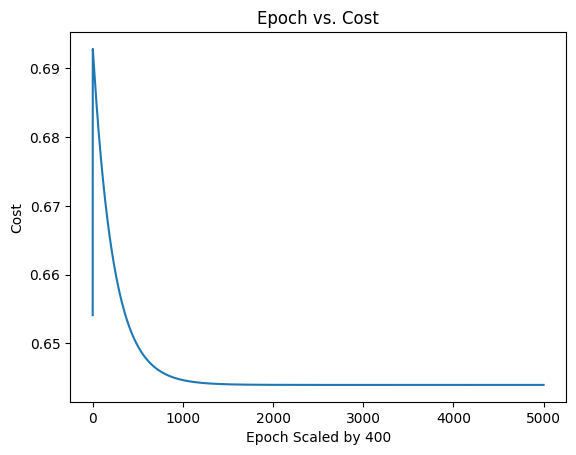

In [44]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="he", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: deep
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6526423675980534; Duration: 8.397
Epoch 800; Cost: 0.6455819397832961; Duration: 7.312
Epoch 1200; Cost: 0.644281406943187; Duration: 7.367
Epoch 1600; Cost: 0.6440334570582341; Duration: 9.01
Epoch 2000; Cost: 0.6439854058071675; Duration: 8.687
Epoch 2400; Cost: 0.643976024356396; Duration: 9.778
Epoch 2800; Cost: 0.6439741866393331; Duration: 9.682
Epoch 3200; Cost: 0.6439738261190863; Duration: 11.037
Epoch 3600; Cost: 0.6439737553463672; Duration: 9.531
Epoch 4000; Cost: 0.6439737414491257; Duration: 12.845
Epoch 4400; Cost: 0.6439737387198498; Duration: 9.447
Epoch 4800; Cost: 0.6439737381838175; Duration: 9.07
Epoch 5000; Cost: 0.6439737381108674; Duration: 0.051
____

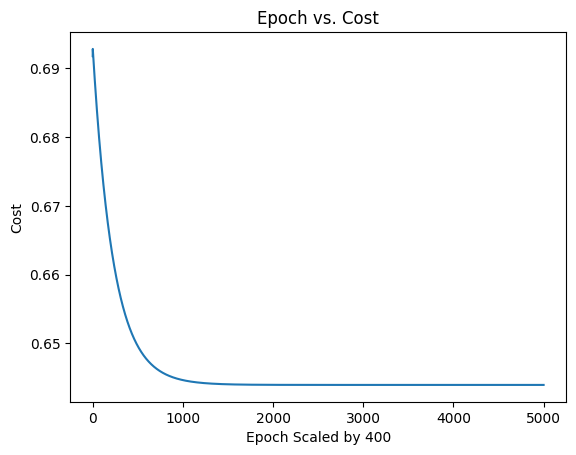

In [45]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="deep", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: xavier
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6526486370530209; Duration: 9.401
Epoch 800; Cost: 0.6455830738053354; Duration: 9.442
Epoch 1200; Cost: 0.6442816211832205; Duration: 8.945
Epoch 1600; Cost: 0.6440334984017935; Duration: 9.149
Epoch 2000; Cost: 0.6439854138636715; Duration: 8.942
Epoch 2400; Cost: 0.6439760259332312; Duration: 8.74
Epoch 2800; Cost: 0.6439741869485573; Duration: 7.398
Epoch 3200; Cost: 0.6439738261797789; Duration: 7.123
Epoch 3600; Cost: 0.6439737553582842; Duration: 8.936
Epoch 4000; Cost: 0.6439737414514661; Duration: 10.909
Epoch 4400; Cost: 0.6439737387203096; Duration: 10.451
Epoch 4800; Cost: 0.6439737381839079; Duration: 16.993
Epoch 5000; Cost: 0.6439737381109074; Duration: 0.02

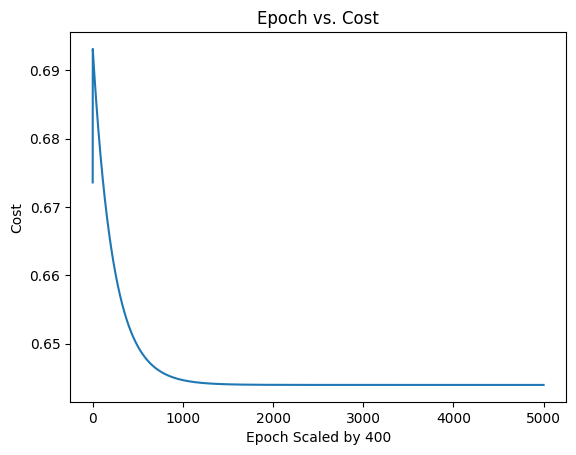

In [46]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="xavier", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: big_random
___________________________________________________________________________________________________


/tmp/ipykernel_12285/1962218587.py:99: RuntimeWarning: overflow encountered in exp
  A = 1 / (1 + np.exp(-Z))
/tmp/ipykernel_12285/1962218587.py:175: RuntimeWarning: divide by zero encountered in log
  cost = - np.sum(np.multiply(Y, np.log(A)) + np.multiply(1 - Y, np.log(1 - A))) / Y.shape[1]
/tmp/ipykernel_12285/1962218587.py:175: RuntimeWarning: invalid value encountered in multiply
  cost = - np.sum(np.multiply(Y, np.log(A)) + np.multiply(1 - Y, np.log(1 - A))) / Y.shape[1]
/tmp/ipykernel_12285/1962218587.py:213: RuntimeWarning: divide by zero encountered in divide
  dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))
/tmp/ipykernel_12285/1962218587.py:213: RuntimeWarning: invalid value encountered in divide
  dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))
/tmp/ipykernel_12285/1962218587.py:115: RuntimeWarning: overflow encountered in exp
  A = 1 / (1 + np.exp(cache))
/tmp/ipykernel_12285/1962218587.py:116: RuntimeWarning: invalid value encountered in multiply
  dZ = dA * A * (1 

Epoch 400; Cost: nan; Duration: 9.058
Epoch 800; Cost: nan; Duration: 9.795
Epoch 1200; Cost: nan; Duration: 7.332
Epoch 1600; Cost: nan; Duration: 7.598
Epoch 2000; Cost: nan; Duration: 7.331
Epoch 2400; Cost: nan; Duration: 7.445
Epoch 2800; Cost: nan; Duration: 7.666
Epoch 3200; Cost: nan; Duration: 7.479
Epoch 3600; Cost: nan; Duration: 7.696
Epoch 4000; Cost: nan; Duration: 8.234
Epoch 4400; Cost: nan; Duration: 8.325
Epoch 4800; Cost: nan; Duration: 8.877
Epoch 5000; Cost: nan; Duration: 0.017
____________________________________
Train Accuracy: 0.6555023923444976
Test Accuracy: 0.3400000000000001
____________________________________


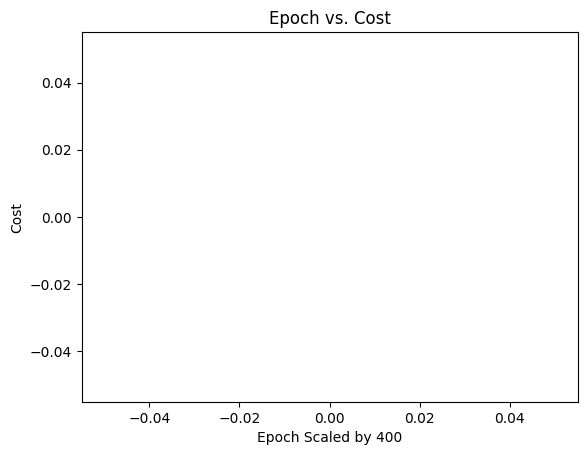

In [47]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="big_random", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: small_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6526403586842975; Duration: 7.78
Epoch 800; Cost: 0.6455815764040758; Duration: 8.151
Epoch 1200; Cost: 0.6442813382928154; Duration: 9.649
Epoch 1600; Cost: 0.6440334438101879; Duration: 8.233
Epoch 2000; Cost: 0.6439854032255529; Duration: 8.096
Epoch 2400; Cost: 0.6439760238511166; Duration: 11.566
Epoch 2800; Cost: 0.643974186540246; Duration: 9.211
Epoch 3200; Cost: 0.6439738260996382; Duration: 8.266
Epoch 3600; Cost: 0.6439737553425484; Duration: 7.904
Epoch 4000; Cost: 0.6439737414483759; Duration: 8.866
Epoch 4400; Cost: 0.6439737387197029; Duration: 8.013
Epoch 4800; Cost: 0.6439737381837886; Duration: 8.612
Epoch 5000; Cost: 0.6439737381108548; Duration: 0

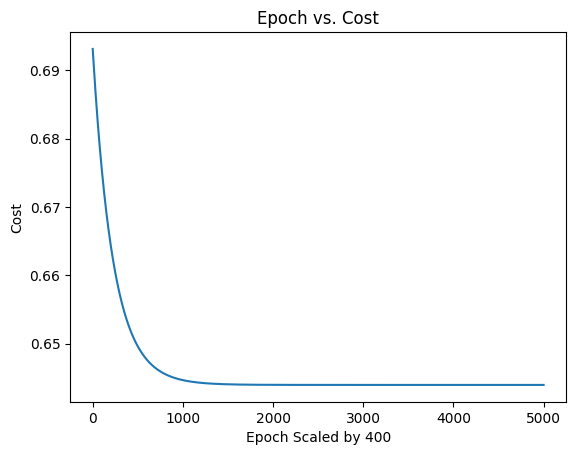

In [48]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="small_random", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: wb_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6529142427052517; Duration: 7.43
Epoch 800; Cost: 0.6456311246841981; Duration: 8.146
Epoch 1200; Cost: 0.6442906968723521; Duration: 12.219
Epoch 1600; Cost: 0.6440352495871807; Duration: 11.736
Epoch 2000; Cost: 0.6439857550924871; Duration: 9.068
Epoch 2400; Cost: 0.6439760927174906; Duration: 8.18
Epoch 2800; Cost: 0.6439742000450828; Duration: 8.612
Epoch 3200; Cost: 0.6439738287502771; Duration: 7.547
Epoch 3600; Cost: 0.6439737558629999; Duration: 8.195
Epoch 4000; Cost: 0.6439737415505836; Duration: 7.843
Epoch 4400; Cost: 0.6439737387397761; Duration: 8.081
Epoch 4800; Cost: 0.6439737381877311; Duration: 7.991
Epoch 5000; Cost: 0.6439737381126018; Duration: 0.0

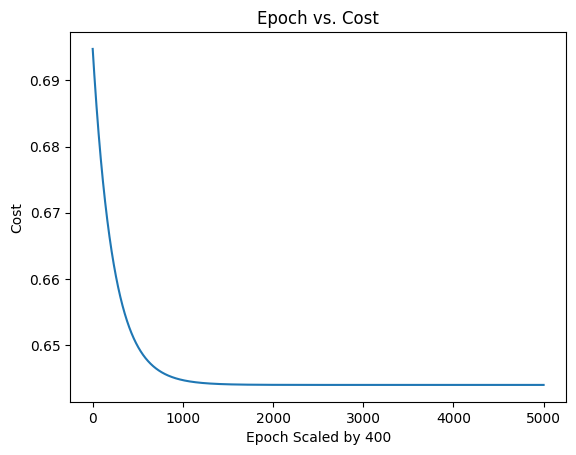

In [49]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="wb_random", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.009; Initialization Method: uniform_random
___________________________________________________________________________________________________
Epoch 400; Cost: 0.6526380874693798; Duration: 7.747
Epoch 800; Cost: 0.6455811655754523; Duration: 9.189
Epoch 1200; Cost: 0.6442812606778626; Duration: 11.688
Epoch 1600; Cost: 0.6440334288321393; Duration: 11.564
Epoch 2000; Cost: 0.6439854003068146; Duration: 15.386
Epoch 2400; Cost: 0.6439760232798547; Duration: 9.285
Epoch 2800; Cost: 0.6439741864282189; Duration: 8.599
Epoch 3200; Cost: 0.6439738260776501; Duration: 9.382
Epoch 3600; Cost: 0.6439737553382313; Duration: 9.192
Epoch 4000; Cost: 0.6439737414475278; Duration: 14.711
Epoch 4400; Cost: 0.6439737387195364; Duration: 11.57
Epoch 4800; Cost: 0.6439737381837559; Duration: 10.288
Epoch 5000; Cost: 0.6439737381108402; Dur

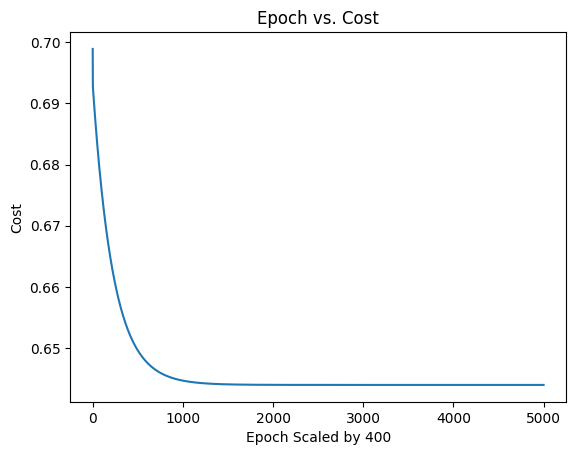

In [50]:
parameters = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
                   init="uniform_random", num_epochs=5000, learning_rate=0.009, print_cost=True, epsilon=400)

In [54]:
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.show()
    

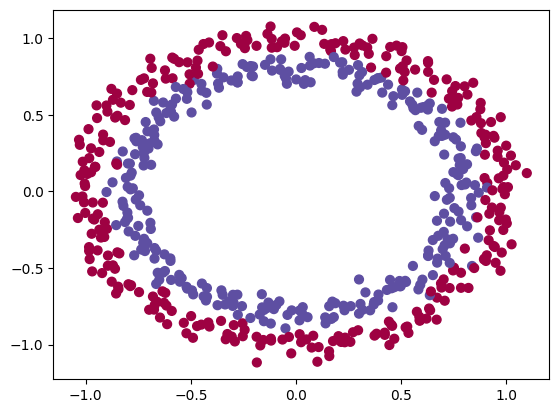

In [62]:
np.random.seed(1)
train_X, train_Y = sklearn.datasets.make_circles(n_samples=600, noise=.05)
np.random.seed(2)
test_X, test_Y = sklearn.datasets.make_circles(n_samples=100, noise=.05)


plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
train_X = train_X.T
train_Y = train_Y.reshape((1, train_Y.shape[0]))
test_X = test_X.T
test_Y = test_Y.reshape((1, test_Y.shape[0]))

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 5000; Learning Rate: 0.01; Initialization Method: he
___________________________________________________________________________________________________
Epoch 1000; Cost: 0.6444205718242304; Duration: 17.921
Epoch 2000; Cost: 0.6439784864495706; Duration: 17.857
Epoch 3000; Cost: 0.6439737895572315; Duration: 17.83
Epoch 4000; Cost: 0.6439737386126646; Duration: 17.532
Epoch 5000; Cost: 0.6439737380588929; Duration: 22.724
Epoch 5000; Cost: 0.6439737380588929; Duration: 0.057
____________________________________
Train Accuracy: 0.6555023923444976
Test Accuracy: 0.3400000000000001
____________________________________


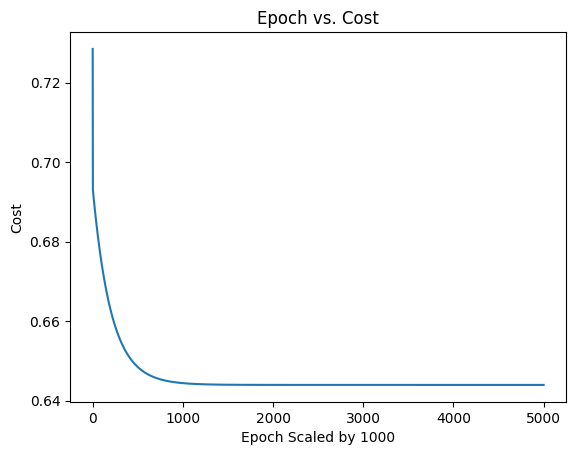

In [63]:
test1 = model(X_train, Y_train, X_test, Y_test, [10, 6], hidden_activation="relu", output_activation="sigmoid", 
              init="he", num_epochs=5000, learning_rate=0.01, print_cost=True, epsilon=1000)